## What is Policy in RL?

In Reinforcement Learning (RL), a  **policy**  is a strategy that an agent uses to decide which action to take in a given state.

> **Deterministic Policy (π(s))**  → Always selects the same action for a given state.
> 
> **Stochastic Policy (π(a|s))**  → Defines a probability distribution over actions for a given state.

**_The goal in RL is to `learn an optimal policy` (π*) `that maximizes cumulative reward._**`

## What is the Value function?

The  **value function**  tells us how good a state or action is in terms of future rewards.

-   **State value (V)**  → How good it is to be in a state.
-   **Action value (Q)**  → How good it is to take a specific action in a state.

**_How it connects to policy:_**

- A  **policy**  decides what actions to take.
> 
- The  **value function**  helps improve the policy by estimating which states/actions lead to higher rewards.
> 
> The better the value estimates, the better the policy can become!

## What is the Critic-Actor model in RL?

Quite similar to GANs where we’ve Generator and Discriminator models fighting throughout the training, a similar concept exists in RL Actor-Critic-Models where :

**Actor-Critic (A2C, A3C)**  is a popular RL architecture that combines two components:

1.  **Actor**  — Learns the  **policy**  (πθ) and decides actions.
2.  **Critic**  — Evaluates the  **value function**  (V(s)) to guide the actor.

## How it works:

-   The  **actor**  updates the policy based on the critic’s feedback.
-   The  **critic**  estimates the expected reward and reduces variance in learning.


### Overview of RLHF

- `RLHF is a technique that enhances pre-trained language or behavior models by aligning them with human values and preferences`. 
- Instead of solely learning from raw data, the model also incorporates human evaluations—typically in the form of `rankings` or `ratings—which serve as rewards` in a reinforcement learning (RL) setup. 
- This process improves the model’s performance by teaching it what humans consider “good” behavior.

**Key idea:**  
- **Pretrained Model → Supervised Fine-Tuning → Reward Model Creation → Reinforcement Learning (e.g., PPO)**

---

### Stage 1: RLHF Step 1: Supervised finetuning of the pretrained model
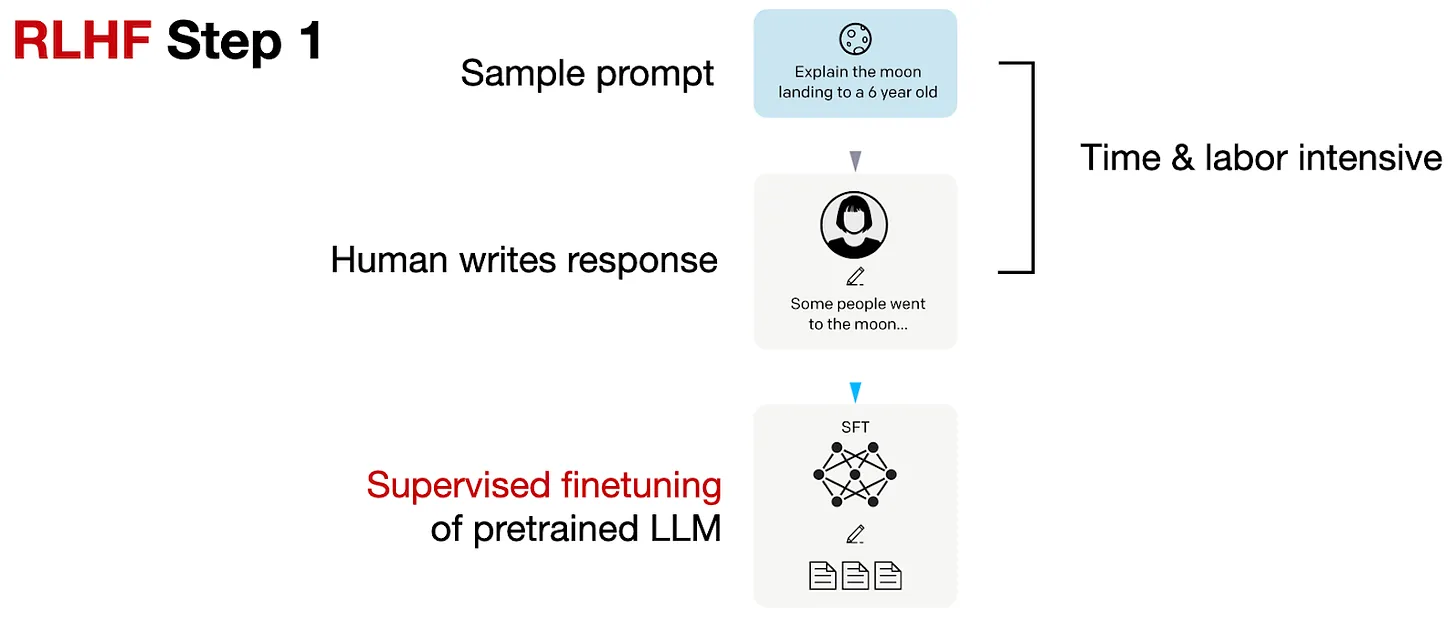
1. **Collecting Prompts and Human-Written Responses:**  
   A dataset is gathered where human experts write high-quality responses to various prompts.  
2. **Fine-Tuning the Base Model:**  
   The pretrained model is then fine-tuned on this dataset in a supervised manner. This is similar to standard language model training but with an emphasis on human-aligned outputs.

*Interactive Tip:*  
Imagine teaching a child by showing correct answers to homework problems—the model learns by example.

---

### Stage 2: Building a Reward Model
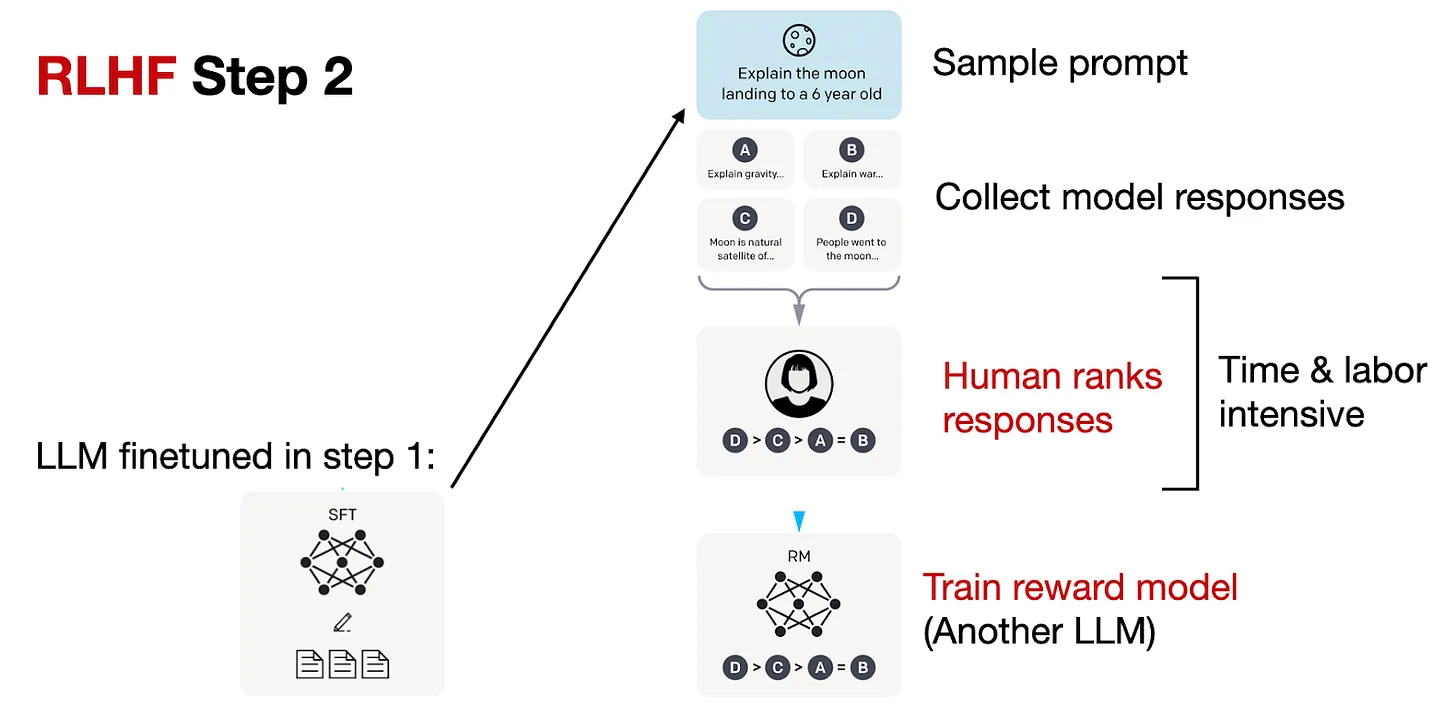
1. **Generating Multiple Responses:**  
   - The fine-tuned model generates several responses for each prompt.  
2. **Human Ranking:**  
   - Humans rank these responses according to quality, ease of understanding, or alignment with intended behavior.  
3. **Training the Reward Model:**  
   - The reward model (often derived from the fine-tuned model) is then trained on this ranked data to output a numerical score (reward) that reflects human preference.

* Tip:*  
Think of the reward model as a “taste tester” that scores various dishes; the higher the score, the better the dish aligns with the desired flavor.

>  Let's refer to te reward model as `RM` and the LLM from the supervised finetuning step as `SFT`. To turn the model from `RLHF Step 1` into a `reward model`, its output layer (t`he next-token classification layer`) is substituted with a regression layer, which features a single output node.
---

### Stage 3: RLHF Step 3: Finetuning via proximal policy optimization
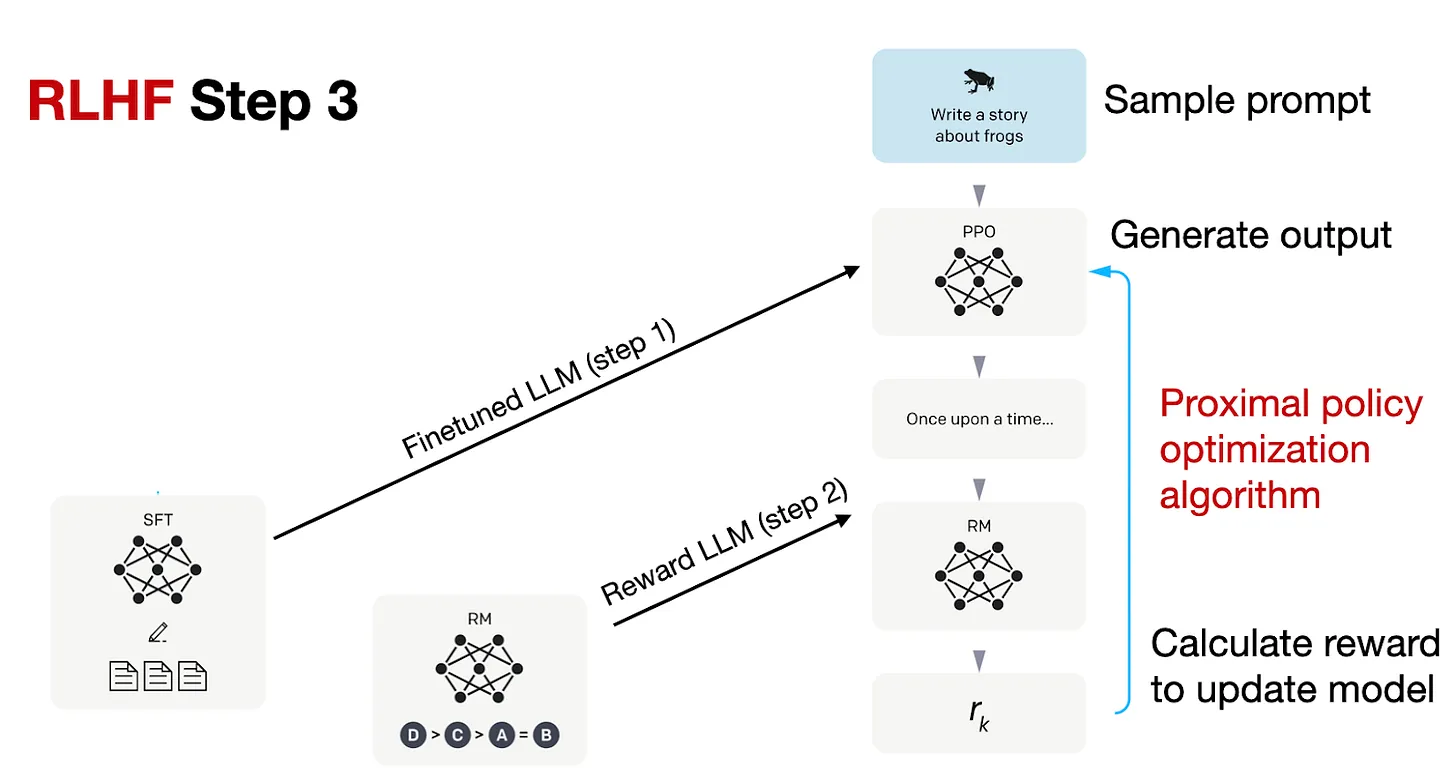
1. **Using the Reward Model for RL:**  
   The reward model’s scores guide further training. The model now acts as an RL agent, generating responses and receiving rewards.  
2. **Proximal Policy Optimization (PPO):**  
   PPO is used to update the model’s policy. It ensures that updates do not deviate too much from the original fine-tuned model, balancing exploration (trying new responses) and exploitation (using learned responses).

*Interactive Tip:*  
Imagine a student who tries different problem-solving methods; the ones that yield better results (as judged by a teacher) are reinforced, but the student is also encouraged to keep a balance so as not to forget the basics learned earlier.

---

###  Discussion Points

- **Why RLHF?**  
  RLHF addresses the challenge of defining an explicit reward function for complex tasks (like generating safe, engaging dialogue). Instead, human preferences are used as a guide.

- **Balancing Innovation and Stability:**  
  The PPO step includes a KL divergence term that prevents the model from straying too far from its initial fine-tuned behavior, ensuring that while it adapts, it does not forget its core language abilities.

- **Applications:**  
  RLHF is used in training state-of-the-art chatbots (e.g., ChatGPT, Claude) and can be applied to various domains—from conversational agents and summarization tasks to even robotics and computer vision.

---

### Summary

**RLHF Pipeline Recap:**  
1. **SFT:** Teaches the model through examples (human-written responses).  
2. **Reward Modeling:** Builds a scoring system that captures human judgments.  
3. **RL via PPO:** Uses these scores to refine the model’s responses in an iterative, balanced manner.





#### Lamma-chat 2  RLHF

![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Feef9ddfa-657d-4784-9e87-371e7617143d_1600x768.png)

### 2. Reward Modeling Differences

![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F17d06b15-e1de-49df-907c-65dc26d1fc21_1444x986.png)

**InstructGPT Approach:** 

-   **Single Reward Model:**
    -   Human labelers rank 4–9 model outputs per prompt.
    -   All “k choose 2” pairwise comparisons are used to train one reward model via a cross‑entropy loss.

**Llama‑2‑chat Approach:**

-   **Dual Reward Models:**
    -   Llama‑2‑chat trains **two separate reward models**—one for _helpfulness_ and one for _safety_.
    -   The final reward used for policy optimization is a `linear combination of these two scores`.
    - 
-   **Binary Comparisons with Margin Labels:**
    -   Instead of ranking many responses at once, each labeling round in Llama‑2 presents only two responses (A and B).
    -   Along with the binary preference (A < B), a **margin label** is collected. This margin indicates how much better one response is compared to the other (ranging from “significantly” to “negligibly” better).
    -   The margin is incorporated into the `ranking loss` via a discrete function m(r). 
    -  `A higher margin forces the loss to be larger (i.e. larger gradients) when the difference is small—pushing the model to make more substantial adjustments when needed.`


**Components**

• rθ(x,y): scalar reward score for response y given prompt x.
• σ: Logistic sigmoid function converting the difference into a [0, 1] score.
• yc: Preferred (chosen) response by human annotators.
• yr: Rejected response by human annotators.



### Detailed Explanation

1.  **InstructGPT Loss Function:**  
    The loss function is designed to push the reward model to assign a higher score to the preferred response ycy_c compared to the rejected response yry_r. It is given by:
    
    $$ L=−E(x,yc,yr)[log⁡(σ(rθ(x,yc)−rθ(x,yr)))]L = -\mathbb{E}_{(x, y_c, y_r)}\left[\log\left(\sigma\left(r_\theta(x, y_c) - r_\theta(x, y_r)\right)\right)\right] $$
    
    Here, the sigmoid σ\sigma converts the difference $$  rθ(x,yc)−rθ(x,yr)r_\theta(x, y_c) - r_\theta(x, y_r) $$ into a probability between 0 and 1.
    
2.  **Llama‑2 Loss Function with Margin:**  
    Llama‑2 modifies the above formulation by adding a margin function m(r) that acts as `a discrete indicator of how strong the human preference is between two responses`. The modified loss becomes:
    
   $$  L=−E(x,yc,yr)[log⁡(σ(rθ(x,yc)−rθ(x,yr)−m(r)))]L = -\mathbb{E}_{(x, y_c, y_r)}\left[\log\left(\sigma\left(r_\theta(x, y_c) - r_\theta(x, y_r) - m(r)\right)\right)\right] $$
    
    The margin m(r) can be seen as a “penalty” term:
    -   If human annotators indicate that the preferred response is only slightly better than the rejected one, m(r) might be small.
    -   If the preferred response is significantly better, m(r) is larger, thereby forcing a wider gap between rθ(x,yc)r_\theta(x, y_c) and rθ(x,yr)r_\theta(x, y_r) to reduce the loss.
    
   -  This additional term ensures that the model not only learns to rank responses correctly but also adjusts the strength of its learning signal based on the degree of preference.
    
3.  **Impact on Training:**
    
    -   **Without Margin (InstructGPT):** The loss treats every pairwise difference equally.
    -   **With Margin (Llama‑2):** The loss function is `more sensitive` to the relative quality of responses as judged by humans. Larger margins yield larger gradients, prompting more significant updates to the model weights when the preferred response is much better than the rejected one.

This nuanced approach helps Llama‑2 better capture the subtleties in human feedback, potentially leading to improved alignment in both helpfulness and safety of the model’s responses.


Insight:_  
Imagine comparing two essays. In the InstructGPT setup, you’d rank several essays and all possible pairs would contribute to the training. In Llama‑2‑chat, you simply compare two essays at a time—and also note how much one outperforms the other, which gives a more nuanced signal.

----------

### 3. Reinforcement Learning Strategy

**Llama‑2‑chat:**
![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fd187fa03-982c-4818-bbd7-833d2ef10386_1298x864.png)
-   **Iterative and Multi‑Stage RLHF:**
    -   The training process evolves through multiple stages (RLHF‑V1 to RLHF‑V5), where the` reward models are periodically updated` based on the errors emerging from the Llama‑2‑chat model.
    - 
-   **Rejection Sampling:**
    -   **Rejection sampling** is introduced: `at each training iteration`, the model generates K responses, and the one with the highest combined reward (helpfulness + safety) is chosen for the gradient update.
    -   This process ensures that, at each update step, the model learns only from the “best” responses.
    - 
-   **Final PPO Stage:**
    -   I**n the final stage, PPO is applied again to further refine the policy**. Empirical results suggest that using PPO at the end outperforms a pipeline that relies solely on rejection sampling.

Insight:_  
Think of rejection sampling as a “talent show” where multiple candidates perform and only the best performer is selected to influence future training. Then, the final PPO step fine‑tunes the model’s behavior based on these high‑quality selections.

----------

### 4. Performance Impact

Meta AI’s experiments show that:

-   **Iterative Updates and Dual Reward Models** help improve both the _helpfulness_ and _harmlessness_ (safety) of the final model.
-   **Combining Rejection Sampling with PPO** leads to better performance than using either method alone.
    -   For example, a model trained with PPO in the final stage (RLHF‑v5 with PPO) outperforms one that uses only rejection sampling.
![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F334cb151-1c0d-45e0-ad66-ef4509d022c7_804x748.png)



## **Understanding Target Modules in LLaMA Models**  

### **What Are These Modules?**  
The list of target modules:  
```python
["q_proj", "k_proj", "v_proj", "up_proj", "down_proj", "o_proj", "gate_proj"]
```  
These refer to **projection layers** in transformer-based models like LLaMA. They play a key role in:  
- **Attention Mechanism** (q_proj, k_proj, v_proj, o_proj)  
- **Feed-Forward Network (MLP)** (up_proj, down_proj, gate_proj)  

These layers handle transformations that help the model **understand and generate text** efficiently.  

---

## **Breakdown of Each Module**  

### **1. Attention Mechanism (Focus on Relevant Text)**
These layers are responsible for computing attention scores and deciding which words in a sentence are most important.  

- **q_proj (Query Projection):** Converts input into query vectors to determine which tokens to focus on.  
- **k_proj (Key Projection):** Converts input into key vectors, which are compared with queries to compute attention scores.  
- **v_proj (Value Projection):** Converts input into value vectors, which contain the actual information to be passed forward.  
- **o_proj (Output Projection):** Merges the attention results from multiple attention heads into a single output.  

> **Example:** In "The cat sat on the mat," the model decides how much attention "sat" should give to "cat" by comparing queries (q_proj) and keys (k_proj).  

---

### **2. Feed-Forward Network (Enhancing Expressiveness)**
After attention, each token passes through a feed-forward network to learn more complex patterns.  

- **up_proj (Up Projection):** Expands the input size (e.g., from 4096 to 11008) to capture richer features.  
- **gate_proj (Gate Projection):** Works as a filter, controlling which information from up_proj should be kept (LLaMA uses a gated approach for better performance).  
- **down_proj (Down Projection):** Reduces the size back to match the model’s hidden size, preparing it for the next layer.  

> **Example:** After attending to "cat" in "The cat sat on the mat," these layers help refine the understanding of "sat" in the sentence.  

---

## **Why Are These Important?**
1. **Critical for Model Efficiency** – They determine how well the model understands relationships between words.  
2. **Targeted in Fine-Tuning** – Techniques like **LoRA (Low-Rank Adaptation)** modify these layers to efficiently train models without updating all parameters.  
3. **Unique to LLaMA** – The **gate_proj** layer introduces a **gated mechanism (SwiGLU activation)**, making LLaMA more expressive than traditional transformers.  

> - The **gate_proj layer is unique** to LLaMA and makes it more expressive than standard transformers.  


---

## **Comparing Different Models**
Different models have different names for these layers.  

| Model        | Target Modules Used |
|-------------|--------------------|
| **LLaMA**   | q_proj, k_proj, v_proj, o_proj, up_proj, down_proj, gate_proj |
| **Falcon 7B** | query_key_value, dense, dense_h_to_4h, dense_4h_to_h |
| **OPT-6.7B** | q_proj, v_proj |
| **Flan-T5** | q, v |




### Fine-Tuning with Preference Alignment: 

#### **Why Traditional SFT Falls Short**
- Supervised Fine-Tuning (SFT) is great for specific tasks but fails to adapt to diverse human preferences or rare situations.

---

#### **What is Preference Alignment?**
- A method to teach AI systems to reflect human preferences by using feedback from humans or AI.
- Focuses on making AI outputs relatable and authentic.

#### **How to Align Models?**
1. **Create a Preference Dataset**: Collect and format data based on what humans value.


#### **Benefits of Preference Alignment**
- Makes chat models more conversational.
- Helps creative models generate authentic content.
- Aligns AI assistants with specific tones, e.g., empathetic customer support.

### Preference Data: Key Concepts and Benefits

#### **What is Preference Data?**
- Unlike standardized instruction datasets, preference data involves multiple responses to an instruction, ranked based on human or AI feedback.
- **Key Feature**: Each instruction has:
  - A **preferred response** (desired behavior).
  - A **rejected response** (undesired behavior).

---

#### **Dataset Format**
- **Objective**: Train the model to prioritize generating preferred responses over rejected ones.
- **Example**:
  - **Instruction**: Tell me a joke about octopuses.
  - **Chosen Answer**: Why don’t octopuses play cards in casinos? Because they can’t count past eight.
  - **Rejected Answer**: How many tickles does it take to make an octopus laugh? Ten tickles.

---

#### **Why Are Rejected Responses Important?**
- They define the undesired behavior to be avoided during model training.
- Without them, the dataset would merely be an instruction set, limiting its refinement capabilities.

---

#### **Advantages of Preference Datasets Over SFT**
1. **Flexibility**: Adaptable to subjective human judgments and complex scenarios.
2. **Behavior Elimination**: Helps eliminate undesired outputs by training against rejected responses.
3. **Better Human Alignment**: Produces models that align outputs with nuanced human preferences.

### Reinforcement Learning with Human Feedback (RLHF): Key Concepts

#### **Core Components of RLHF**
1. **Reward Model Learning**:
   - **Purpose**: Learn a reward function from human feedback instead of using a predefined one.
   - **Process**:
     - Present multiple answers to humans for a given task.
     - Train the reward model based on human preferences, often using techniques like the Bradley-Terry model to map preferences to utility.

2. **Policy Optimization**:
   - **Purpose**: Improve the model’s behavior using the learned reward model.
   - **Process**:
     - Use standard reinforcement learning (RL) algorithms to maximize predicted rewards.
     - Policies iteratively adapt to become more aligned with human preferences.

3. **Iterative Improvement**:
   - **Purpose**: Continuously refine the reward model and policy through human feedback.
   - **Process**:
     - Improved policies generate new behaviors.
     - These behaviors are evaluated by humans, further training the reward model.

---

#### **Handling Human Feedback Costs**
- **Key Innovation**: RLHF reduces reliance on continuous human supervision by:
  - Using **asynchronous** and **sparse feedback**.
  - Training a reward model as a proxy for human preferences, enabling independent reinforcement learning without human input at every step.

#### **Example: Proximal Policy Optimization (PPO) in RLHF**


![](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781836200079/files/Images/B31105_06_04.png)


- **Overview**:
  - Reward model scores text generated by the model.
  - Includes KL-divergence regularization to maintain token distribution similar to the pre-trained model.
- **Impact**:
  - Allows the model to retain pre-trained knowledge while aligning its output with human preferences.


#### **Challenges of RLHF**
- **Iterative Nature**: Computationally expensive and potentially unstable.
- **Underperformance**: Despite theoretical advantages, RLHF can experimentally lag behind simpler methods like Direct Preference Optimization (DPO).

### Direct Preference Optimization (DPO): 
![](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781836200079/files/Images/B31105_06_05.png)
#### **What is DPO?**
- **Introduced By**: Rafailov et al., 2023.
- **Purpose**: Streamlines preference learning as an alternative to RLHF by removing the need for a separate reward model and reinforcement learning (RL) algorithms.
- **Core Insight**: Reformulates the learning problem to directly optimize the policy using a mathematical expression for reward maximization with a KL-divergence constraint.

---

#### **How Does DPO Work?**
1. **Optimization**:
   - Uses **binary cross-entropy loss** directly on the model’s output probabilities.
   - Encourages higher probabilities for **preferred responses** and lower for **non-preferred responses**.
2. **Reference Model**:
   - Maintains similarity to a frozen reference model through a **beta parameter** (common value: 0.1).
   - **Beta = 0**: No influence from the reference model, allowing greater divergence.
3. **Efficiency**:
   - Operates without RL techniques like Proximal Policy Optimization (PPO).
   - Optimized using standard gradient descent, avoiding the need for sampling during training.

---

#### **Advantages**
- **Simplicity**:
  - Removes complex RL algorithms and separate reward models.
  - Reduces engineering complexity.
- **Efficiency**:
  - Lower computational cost—ideal for teams with limited resources.
  - Saves VRAM when used with LoRA or QLoRA (only one model needs to be loaded).
- **Stability**:
  - Less sensitive to hyperparameters.
  - Matches or surpasses RLHF performance in most cases.

---

#### **Drawbacks**
- Still requires **paired preference data**, which can be costly and time-consuming to collect.
- Lacks the **theoretical guarantees** of RL-based methods.
- RLHF may perform better in large-scale, complex tasks with millions of preference samples.

#### **When to Use DPO**
- Best suited for projects requiring simplicity, efficiency, and stability.
- Ideal for small to medium-scale applications with limited resources.
- May not replace RLHF in environments requiring dynamic, iterative improvements.




## Odds Ratio Preference Optimization (ORPO)

##### 1. The Problem with Traditional SFT

**Traditional Supervised Fine-Tuning (SFT):**

-   **Objective:** Maximizes the likelihood of generating target tokens by minimizing the negative log-likelihood (NLL).
-   **Limitation:** Although SFT makes the model generate fluent text, it does not include any built-in mechanism to **discourage disfavored responses**. In other words, the loss function only rewards the right answer but never explicitly penalizes an answer that humans would reject.

**Odds Ratio Preference Optimization (ORPO)** is an innovative fine-tuning technique that integrates supervised fine-tuning (SFT) and preference alignment into a single, unified process. This approach enhances efficiency and performance compared to traditional methods like Reinforcement Learning with Human Feedback (RLHF) or Direct Preference Optimization (DPO).

**Understanding ORPO**

Traditional alignment methods, such as DPO, typically involve two separate stages:

1.  **Supervised Fine-Tuning (SFT):** Adapts the model to a specific domain and format.
2.  **Preference Alignment:** Aligns the model's outputs with human preferences.
----------

## 2. Introducing the Odds Ratio

ORPO tackles this limitation by using the concept of **odds** and comparing them between two responses. Let’s break it down:

### A. **Odds of Generating a Sequence**

-   **Definition:**  
    The odds of generating a sequence ( y ) given an input ( x ) can be defined as:
    
    $$ [ \text{Odds}(y|x) = \frac{P(y|x)}{1 - P(y|x)} ] $$
    
    This value tells you how much more likely the model is to output the sequence ( y ) compared to not outputting it.
    
-   **Interpretation:**
    
    -   `A higher odds` value implies the model is "confident" in generating that sequence.
    -   It’s a way to quantify model preference beyond the raw probability.

### B. **Odds Ratio (OR) Between Responses**

-   **Favored vs. Disfavored:**  
    ORPO considers two responses for a given prompt:
    
    -   **Favored response (( y_w ))** – the one humans prefer.
    -   **Disfavored response (( y_l ))** – the one that is rejected.
-   **Odds Ratio Calculation:**
    
    $$ [ \text{OR} = \frac{\text{Odds}(y_w|x)}{\text{Odds}(y_l|x)} ]  $$
    
    This ratio directly compares how much more likely the model is to generate the favored response compared to the disfavored one.
    

**Visualization:**

```
               [Input: x]
                  /  \
     Favored: y_w    Disfavored: y_l
         |                 |
   Compute Odds      Compute Odds
      O_w = P(y_w|x)/(1-P(y_w|x))
      O_l = P(y_l|x)/(1-P(y_l|x))
                  |
         Odds Ratio = O_w / O_l

```

## 3. Designing the Loss Function

### A. **Standard SFT Loss**

-   **Formula:**  
     $$ L_{\text{SFT}} = -\log P(y|x)  $$
    
    This encourages the model to generate the correct tokens as seen in the training data.
    

### B. **Penalty Term Based on Odds Ratio**

-   **Objective:**  
    To **penalize the model** if the odds ratio between the favored and disfavored responses is `not large enough`.
    
-   **Intuition:**  
    If the favored response isn’t substantially more likely than the disfavored one, the model should be “punished” so that it learns to differentiate better.
    
-   **How It Works:**
    
   
        
    2.  **Sigmoid Smoothing:**
        
       ` To make the gradient smoother and prevent abrupt changes during optimization, the log odds ratio is passed through a sigmoid function`. This keeps the penalty continuous and differentiable.
        
-   **Penalty Term  $$ (( L_{\text{OR}} ))  $$:**  
    While the exact formulation may vary, the idea is:
    
     $$L_{\text{OR}} = \text{sigmoid} \left(\log\frac{\text{Odds}(y_w|x)}{\text{Odds}(y_l|x)}\right) $$
    
    This term increases (i.e., the penalty becomes larger) when the log odds ratio is low.
    

### C. **Overall ORPO Loss Function**

-   **Combined Loss:**  
    ORPO uses a weighted sum of the standard SFT loss and the odds ratio penalty:
    
     $$ L_{\text{total}} = L_{\text{SFT}} + \lambda \cdot L_{\text{OR}} $$
    
    Where:
        -  `Lambda`     is a hyperparameter that controls the strength of the penalty.
    -   A higher  lambda forces the model to focus more on differentiating between favored and disfavored responses.

----------

## 4. Summary of ORPO’s Approach

1.  **Traditional SFT lacks an explicit penalty for disfavored outputs.**  
    ORPO fills this gap by incorporating a new penalty term.
    
2.  **Odds and Odds Ratio Calculation:**
    
    -   **Odds:** Measures how likely a response is generated.
    -   **Odds Ratio:** Compares the favored (( y_w )) and disfavored (( y_l )) outcomes.
3.  **Loss Function Composition:**
    
    -   **SFT Loss:** Maintains general language modeling capabilities.
        
    -   **Odds Ratio Penalty (( L_{\text{OR}} )):** Encourages the model to prefer the favored responses.
        
    -   **Combined Objective:**
        
         $$[ L_{\text{total}} = L_{\text{SFT}} + \lambda \cdot L_{\text{OR}} ] $$
        
   